### Assumptions

1. Small resistances $B_{kl} = \frac{X_{kl}}{R^2_{kl}+X_{kl}^2} \approx X_{kl}^{-1}$ **justfified?** Compare to Def. 2.20 (Fischer)
2. Off-Diagonal Elements $B[i,j] = - b_{ij}$, Diagonal $B[i,i] = \sum_j B_{}ij$
3. DC Power Approximation $P_{kl} = \frac{\theta_k - \theta_l}{X_{kl}} \implies B \theta = P$ **What do we need Gains/Loads for?**

/var/folders/k8/5xy7bhr17fzf7mjz020r261r0000gn/T/ipykernel_2053/3652886654.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  susceptances = [1/(branch.reactance) for branch in branches] # Assuming small resistances


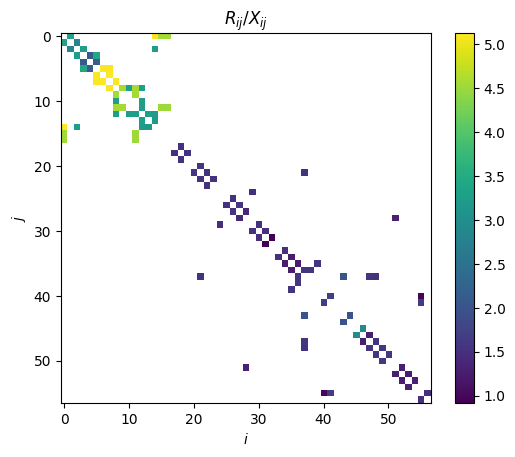

In [ ]:
from powergrid import *
import networkx as nx
import matplotlib.pyplot as plt


# Justifying small resistance approxmation -> Plot R_kl / X_kl
branch_data = np.loadtxt('data/ieee57_branch.csv', delimiter=',', skiprows=1, dtype=str)
tap_bus_number = np.array(branch_data[:, 0], dtype=float) # units?
z_bus_number = np.array(branch_data[:, 1], dtype=float) # 
reactances = np.array(branch_data[:, 7], dtype=float) 
resistances = np.array(branch_data[:, 6], dtype=float) 

branches_reactance = [Branch(tap_bus_number[i], z_bus_number[i], reactances[i]) for i in range(len(branch_data))] 
branches_resistance = [Branch(tap_bus_number[i], z_bus_number[i], resistances[i]) for i in range(len(branch_data))] 

n = PowerGrid.ieee57().n

def susceptance_graph(branches: list[Branch]):
        edges = [(branch.from_bus-1, branch.to_bus-1) for branch in branches] # switch to 0-indexing
        rows, cols = zip(*edges)
        susceptances = [1/(branch.reactance) for branch in branches] # Assuming small resistances
        graph = csr_matrix((susceptances, (rows, cols)), shape=(n, n))  # Undirected Graph with weights corresponding to susceptances 
        graph += graph.T
        return graph

reactance_graph = susceptance_graph(branches_reactance)
resistance_graph = susceptance_graph(branches_resistance)

resistance_graph

ratios = resistance_graph / reactance_graph  

plt.imshow(ratios)
plt.colorbar()
plt.xlabel(r'$i$')
plt.ylabel(r'$j$')
plt.title(r'$R_{ij}/X_{ij}$')
plt.show()

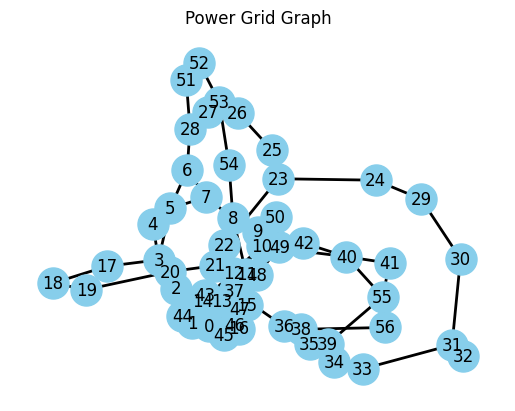

<class 'scipy.sparse._csc.csc_matrix'>
(57, 57)
(57, 1)
<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 42 stored elements and shape (57, 1)>
  Coords	Values
  (0, 0)	73.9
  (1, 0)	-3.0
  (2, 0)	-1.0
  (4, 0)	-13.0
  (5, 0)	-75.0
  (7, 0)	300.0
  (8, 0)	-121.0
  (9, 0)	-5.0
  (11, 0)	-67.0
  (12, 0)	-18.0
  (13, 0)	-10.5
  (14, 0)	-22.0
  (15, 0)	-43.0
  (16, 0)	-42.0
  (17, 0)	-27.2
  (18, 0)	-3.3
  (19, 0)	-2.3
  (22, 0)	-6.3
  (24, 0)	-6.3
  (26, 0)	-9.3
  (27, 0)	-4.6
  (28, 0)	-17.0
  (29, 0)	-3.6
  (30, 0)	-5.8
  (31, 0)	-1.6
  (32, 0)	-3.8
  (34, 0)	-6.0
  (37, 0)	-14.0
  (40, 0)	-6.3
  (41, 0)	-7.1
  (42, 0)	-2.0
  (43, 0)	-12.0
  (46, 0)	-29.7
  (48, 0)	-18.0
  (49, 0)	-21.0
  (50, 0)	-18.0
  (51, 0)	-4.9
  (52, 0)	-20.0
  (53, 0)	-4.1
  (54, 0)	-6.8
  (55, 0)	-7.6
  (56, 0)	-6.7


In [ ]:
#Plot Power Grid Graph

pg = PowerGrid.ieee57()

G = nx.from_scipy_sparse_array(pg.graph)

pos = nx.spring_layout(G)  # layout of the nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)

# Draw edges
nx.draw_networkx_edges(G, pos, width=2)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12)

plt.title("Power Grid Graph")
plt.axis('off')
plt.show()


#print(pg.B)
print(type(pg.P))
print(pg.B.shape)
print(pg.P.shape)
print(pg.P)
# Why do we have disconnected 